<a href="https://colab.research.google.com/github/FemX-AI/FIFA-PLAYER-RATING-PREDICTOR/blob/main/ml_fifa_ovr_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("stefanoleone992/fifa-22-complete-player-dataset")

100%|██████████| 109M/109M [00:01<00:00, 91.3MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

In [3]:
df_path = os.path.join(path, "players_22.csv")
df = pd.read_csv(df_path)
print(f"{path} :\n{df_path}")

/tmp/ipykernel_210/4046860121.py:2: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


/root/.cache/kagglehub/datasets/stefanoleone992/fifa-22-complete-player-dataset/versions/3 :
/root/.cache/kagglehub/datasets/stefanoleone992/fifa-22-complete-player-dataset/versions/3/players_22.csv


# Data preprocessing .


In [6]:
df.isnull().sum()
# Checking the cols with missing values .
df_cleaned = df.dropna(axis = 1)

In [7]:
# Dropping columns with url .
http_cols = [col for col in df_cleaned.columns if 'url' in col]
df_cleaned = df_cleaned.drop(columns=http_cols)
print(f"Columns dropped: {http_cols}")
display(df_cleaned.head())

Columns dropped: ['player_url', 'player_face_url', 'nation_flag_url']


,sofifa_id,short_name,long_name,player_positions,overall,potential,age,dob,height_cm,weight_kg,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,34,1987-06-24,170,72,...,64+3,64+3,64+3,66+3,61+3,50+3,50+3,50+3,61+3,19+3
1,188545,R. Lewandowski,Robert Lewandowski,ST,92,92,32,1988-08-21,185,81,...,66+3,66+3,66+3,64+3,61+3,60+3,60+3,60+3,61+3,19+3
2,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,36,1985-02-05,187,83,...,59+3,59+3,59+3,63+3,60+3,53+3,53+3,53+3,60+3,20+3
3,190871,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,29,1992-02-05,175,68,...,63+3,63+3,63+3,67+3,62+3,50+3,50+3,50+3,62+3,20+3
4,192985,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,30,1991-06-28,181,70,...,80+3,80+3,80+3,79+3,75+3,69+3,69+3,69+3,75+3,21+3


In [8]:
df_cleaned['Year'] = pd.to_datetime(df_cleaned['dob']).dt.year
df_cleaned.drop(columns = ["dob", "long_name" , "sofifa_id" , "player_positions"], inplace = True)
#df_cleaned["Year"]


In [9]:
df_cleaned["att_work_rate"] = df_cleaned["work_rate"].apply(lambda x: x.split("/")[0])
df_cleaned["df_work_rate"] = df_cleaned["work_rate"].apply(lambda x: x.split("/")[1])

"""
Creating a new column that keeps the first position of the player ,
the dropping the old column .
"""
df_cleaned.drop(columns = ["work_rate"], inplace = True)

In [10]:
df_cleaned

,short_name,overall,potential,age,height_cm,weight_kg,nationality_id,nationality_name,preferred_foot,weak_foot,...,rwb,lb,lcb,cb,rcb,rb,gk,Year,att_work_rate,df_work_rate
0,L. Messi,93,93,34,170,72,52,Argentina,Left,4,...,66+3,61+3,50+3,50+3,50+3,61+3,19+3,1987,Medium,Low
1,R. Lewandowski,92,92,32,185,81,37,Poland,Right,4,...,64+3,61+3,60+3,60+3,60+3,61+3,19+3,1988,High,Medium
2,Cristiano Ronaldo,91,91,36,187,83,38,Portugal,Right,4,...,63+3,60+3,53+3,53+3,53+3,60+3,20+3,1985,High,Low
3,Neymar Jr,91,91,29,175,68,54,Brazil,Right,5,...,67+3,62+3,50+3,50+3,50+3,62+3,20+3,1992,High,Medium
4,K. De Bruyne,91,91,30,181,70,7,Belgium,Right,5,...,79+3,75+3,69+3,69+3,69+3,75+3,21+3,1991,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,Song Defu,47,52,22,180,64,155,China PR,Right,3,...,48+2,48+2,46+2,46+2,46+2,48+2,15+2,1999,Medium,Medium
19235,C. Porter,47,59,19,175,70,25,Republic of Ireland,Right,3,...,49+2,48+2,44+2,44+2,44+2,48+2,14+2,2002,Medium,Medium
19236,N. Logue,47,55,21,178,72,25,Republic of Ireland,Right,3,...,47+2,47+2,45+2,45+2,45+2,47+2,12+2,2000,Medium,Medium
19237,L. Rudden,47,60,19,173,66,25,Republic of Ireland,Right,3,...,33+2,32+2,26+2,26+2,26+2,32+2,15+2,2002,Medium,Medium


In [11]:
df_cleaned.columns

Index(['short_name', 'overall', 'potential', 'age', 'height_cm', 'weight_kg',
       'nationality_id', 'nationality_name', 'preferred_foot', 'weak_foot',
       'skill_moves', 'international_reputation', 'body_type', 'real_face',
       'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'power_shot_power',
       'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
       'mentality_aggression', 'mentality_interceptions',
       'mentality_positioning', 'mentality_vision', 'mentality_penalties',
       'mentality_composure', 'defending_marking_awareness',
       'defending_standing_tackle', 'defending_sliding_tackle',
       'goalkeeping_diving', 'goalkee

In [12]:
# Converting height_cm to height_ft .
df_cleaned["height_ft"] = df_cleaned["height_cm"] / 30.48
df_cleaned["height_ft"] = round(df_cleaned["height_ft"], 1)

In [13]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   short_name                   19239 non-null  object 
 1   overall                      19239 non-null  int64  
 2   potential                    19239 non-null  int64  
 3   age                          19239 non-null  int64  
 4   height_cm                    19239 non-null  int64  
 5   weight_kg                    19239 non-null  int64  
 6   nationality_id               19239 non-null  int64  
 7   nationality_name             19239 non-null  object 
 8   preferred_foot               19239 non-null  object 
 9   weak_foot                    19239 non-null  int64  
 10  skill_moves                  19239 non-null  int64  
 11  international_reputation     19239 non-null  int64  
 12  body_type                    19239 non-null  object 
 13  real_face       

In [14]:
cols_to_drop = ["real_face" ,"nationality_id", "preferred_foot" ,"weak_foot", "nationality_name" , "body_type" , "height_cm" ]
"""
Dropping less important features .
"""
df_cleaned.drop(columns = cols_to_drop, inplace = True)
df_cleaned.head()

# Checking the if values are successful dropped .

,short_name,overall,potential,age,weight_kg,skill_moves,international_reputation,attacking_crossing,attacking_finishing,attacking_heading_accuracy,...,lb,lcb,cb,rcb,rb,gk,Year,att_work_rate,df_work_rate,height_ft
0,L. Messi,93,93,34,72,4,5,85,95,70,...,61+3,50+3,50+3,50+3,61+3,19+3,1987,Medium,Low,5.6
1,R. Lewandowski,92,92,32,81,4,5,71,95,90,...,61+3,60+3,60+3,60+3,61+3,19+3,1988,High,Medium,6.1
2,Cristiano Ronaldo,91,91,36,83,5,5,87,95,90,...,60+3,53+3,53+3,53+3,60+3,20+3,1985,High,Low,6.1
3,Neymar Jr,91,91,29,68,5,5,85,83,63,...,62+3,50+3,50+3,50+3,62+3,20+3,1992,High,Medium,5.7
4,K. De Bruyne,91,91,30,70,4,4,94,82,55,...,75+3,69+3,69+3,69+3,75+3,21+3,1991,High,High,5.9


In [15]:
def adding_str():
  for col in df_cleaned.columns:
    # Check if the column is of object type (likely string) and if any value contains '+'
    # Use .astype(str) to handle potential non-string types and .str.contains for regex check
    # Escape '+' as it's a special character in regex
    if df_cleaned[col].dtype == 'object' and df_cleaned[col].str.contains(r'\+').any():
      # Apply eval only to string values that contain '+'
      df_cleaned[col] = df_cleaned[col].apply(lambda x: eval(x) if isinstance(x, (str , int)) and '+' in x else x)
      # Explicitly convert the column to numeric after eval, coercing errors to NaN
      df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0).astype(int)

# Call the function to apply the changes
adding_str()

# Display the head to see the changes
display(df_cleaned.head())

,short_name,overall,potential,age,weight_kg,skill_moves,international_reputation,attacking_crossing,attacking_finishing,attacking_heading_accuracy,...,lb,lcb,cb,rcb,rb,gk,Year,att_work_rate,df_work_rate,height_ft
0,L. Messi,93,93,34,72,4,5,85,95,70,...,64,53,53,53,64,22,1987,Medium,Low,5.6
1,R. Lewandowski,92,92,32,81,4,5,71,95,90,...,64,63,63,63,64,22,1988,High,Medium,6.1
2,Cristiano Ronaldo,91,91,36,83,5,5,87,95,90,...,63,56,56,56,63,23,1985,High,Low,6.1
3,Neymar Jr,91,91,29,68,5,5,85,83,63,...,65,53,53,53,65,23,1992,High,Medium,5.7
4,K. De Bruyne,91,91,30,70,4,4,94,82,55,...,78,72,72,72,78,24,1991,High,High,5.9


Let's check the unique values of one of the `object` type columns, for example, `lw`, to see why it wasn't converted.

In [16]:
print(df_cleaned['lw'].value_counts())

lw
60      773
62      772
64      770
61      769
63      764
       ... 
58-1      1
58-2      1
60-3      1
56-1      1
52-1      1
Name: count, Length: 138, dtype: int64


As you can see, the values in `lw` are numeric strings, but they do not contain the `+` operator. Therefore, the `adding_str` function skipped these columns.

To convert these remaining object columns to integers, we can explicitly apply `pd.to_numeric` to them.

In [17]:
cols_to_convert = ['lw', 'lf', 'cf', 'rf', 'rw']

for col in cols_to_convert:
    # Convert to numeric, coercing errors to NaN, then fill NaN with 0 and convert to int
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0).astype(int)

# Verify the dtypes after conversion
df_cleaned[cols_to_convert].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   lw      19239 non-null  int64
 1   lf      19239 non-null  int64
 2   cf      19239 non-null  int64
 3   rf      19239 non-null  int64
 4   rw      19239 non-null  int64
dtypes: int64(5)
memory usage: 751.7 KB


In [18]:
"""
cols_obj = []
for cols in df_cleaned.columns :
  if df_cleaned[cols].dtype == "object" :
    cols_obj.append(cols)
cols_obj
"""

'\ncols_obj = []\nfor cols in df_cleaned.columns :\n  if df_cleaned[cols].dtype == "object" :\n    cols_obj.append(cols)\ncols_obj\n'

In [19]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Data columns (total 72 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   short_name                   19239 non-null  object 
 1   overall                      19239 non-null  int64  
 2   potential                    19239 non-null  int64  
 3   age                          19239 non-null  int64  
 4   weight_kg                    19239 non-null  int64  
 5   skill_moves                  19239 non-null  int64  
 6   international_reputation     19239 non-null  int64  
 7   attacking_crossing           19239 non-null  int64  
 8   attacking_finishing          19239 non-null  int64  
 9   attacking_heading_accuracy   19239 non-null  int64  
 10  attacking_short_passing      19239 non-null  int64  
 11  attacking_volleys            19239 non-null  int64  
 12  skill_dribbling              19239 non-null  int64  
 13  skill_curve     

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder , StandardScaler

In [21]:
# Converting df["short_names"] to encoded values
encoder = LabelEncoder()
df_cleaned["short_name"] = encoder.fit_transform(df_cleaned["short_name"])
df_cleaned["short_name"]

,short_name
0,10117
1,14468
2,3288
3,13097
4,9005
...,...
19234,16139
19235,2947
19236,12809
19237,10276


In [22]:
# spltting the dataset into feat and target.
X = df_cleaned.drop(columns = ["overall"])
y = df_cleaned["overall"]

In [23]:
# importing ml algorithms , for regression .
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [24]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Data columns (total 72 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   short_name                   19239 non-null  int64  
 1   overall                      19239 non-null  int64  
 2   potential                    19239 non-null  int64  
 3   age                          19239 non-null  int64  
 4   weight_kg                    19239 non-null  int64  
 5   skill_moves                  19239 non-null  int64  
 6   international_reputation     19239 non-null  int64  
 7   attacking_crossing           19239 non-null  int64  
 8   attacking_finishing          19239 non-null  int64  
 9   attacking_heading_accuracy   19239 non-null  int64  
 10  attacking_short_passing      19239 non-null  int64  
 11  attacking_volleys            19239 non-null  int64  
 12  skill_dribbling              19239 non-null  int64  
 13  skill_curve     

In [25]:
# splitting X into numeric and obj dtype .
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
object_cols = X.select_dtypes(include=['object']).columns.tolist()

numeric_cols

Index(['short_name', 'potential', 'age', 'weight_kg', 'skill_moves',
       'international_reputation', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'power_shot_power',
       'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
       'mentality_aggression', 'mentality_interceptions',
       'mentality_positioning', 'mentality_vision', 'mentality_penalties',
       'mentality_composure', 'defending_marking_awareness',
       'defending_standing_tackle', 'defending_sliding_tackle',
       'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'ls', 'st', 'rs',
       'lw', 'lf',

In [26]:
# Using columns transformer.
from sklearn.preprocessing import StandardScaler ,OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers = [
    ("st_cols", StandardScaler(), numeric_cols),
    ("one_cols", OneHotEncoder(handle_unknown="ignore"), ["att_work_rate" , "df_work_rate"]) ,
])

# splitting into training and testing data .
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2)

preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print(X_train_trans.shape , X_test_trans.shape)

(15391, 74) (3848, 74)


In [27]:
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

# fitting the models
dt.fit(X_train_trans , y_train)
rf.fit(X_train_trans , y_train)

RandomForestRegressor()

In [28]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

# making predictions .
Y_pred_dt = dt.predict(X_test_trans)
Y_pred_rf = rf.predict(X_test_trans)

# checking the MSE for the models
dt_evaluate = mean_absolute_error(y_test , Y_pred_dt)
rf_evaluate = mean_absolute_error(y_test , Y_pred_rf)

dt_evaluate , rf_evaluate
#Y_pred_dt[:5] , y_test[:5]

(0.5917359667359667, 0.4401845114345115)

In [29]:
Y_pred_rf[:5] , y_test[:5]

(array([65.98, 63.84, 51.92, 76.97, 71.87]),
 9288     66
 11186    64
 18810    52
 890      77
 3822     72
 Name: overall, dtype: int64)

In [30]:
score_df = pd.DataFrame({"rf_model" :[rf_evaluate],
                          "dt_model" : [dt_evaluate],
                         })
score_df
# Checking the models score .

,rf_model,dt_model
0,0.440185,0.591736


In [31]:
# Getting the features cols .
feature_names = []
feature_names.extend(numeric_cols)
feature_names.extend(preprocessor.named_transformers_["one_cols"].get_feature_names_out())
len(feature_names)

74

In [32]:
# Calculating most feat in the models.
rf_model_feat = rf.feature_importances_
dt_model_feat = dt.feature_importances_

rf_model_feat.max() , dt_model_feat.max()

(np.float64(0.7150008181906892), np.float64(0.7116973390007753))

In [33]:
import matplotlib.pyplot as plt

# Visualizing the rf_model's feat importance.
def visual_feat_models(model):

 model_feat = model.feature_importances_
 importance_feat_df_model = pd.Series(model_feat , index = feature_names)
 sorted_feat_names_model = importance_feat_df_model.sort_values(ascending=False)
 sorted_feat_names_model = sorted_feat_names_model[:10]

 plt.barh(sorted_feat_names_model.index  , sorted_feat_names_model.values)
 plt.xlabel("Feature Importance")
 plt.ylabel("Features")
 plt.title(f"{model}")
 plt.show()

 highest_value = sorted_feat_names_model.iloc[0]
 highest_feature = sorted_feat_names_model.index[0]

 print(f"The highest feature importance value is: {highest_value:.4f}")
 print(f"The feature with the highest importance is: {highest_feature}")


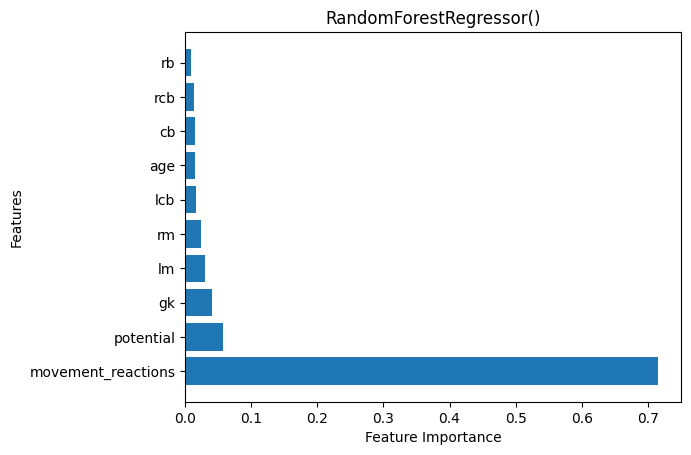

The highest feature importance value is: 0.7150
The feature with the highest importance is: movement_reactions


In [34]:
visual_feat_models(rf)

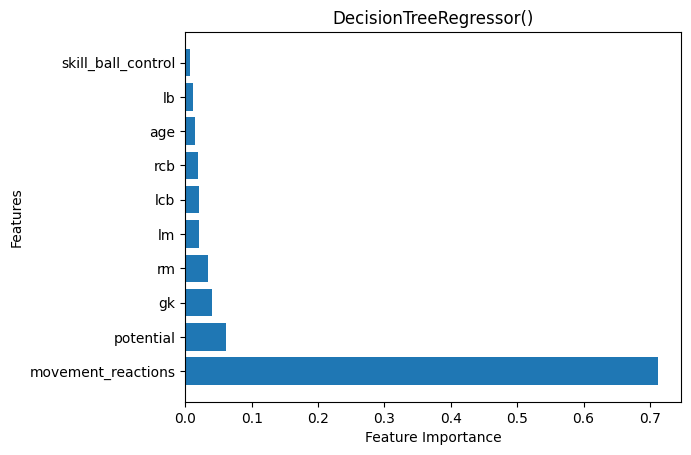

The highest feature importance value is: 0.7117
The feature with the highest importance is: movement_reactions


In [35]:
visual_feat_models(dt)

In [36]:
# Making a function to predict the overall of player  , with just the player's name .
def predict_player_overall(player_name , model):

  # First we encode the name
  try :
     encoded_name = encoder.transform([player_name])[0]
  except ValueError :
    # Return name not found .
    print(f"Invalid input .")
    return None

    # Filtering : printing the rows with that encoded_name .
  player_data = df_cleaned[df_cleaned["short_name"] == encoded_name]

  if player_data is None:
      print(f"{player_name} not found in the dataset")
      return None


    # Dropping the 'overall' column , also re_ordering the feat with X.cols
  player_feat = player_data.drop(columns = ["overall"]).copy()
  player_feat = player_feat[X.columns]

    # preprocessing the data .
  player_feat_trans = preprocessor.transform(player_feat)

  """
    After all this we make predictions using ,
     using rf(Random_Forest_Regressor) , why?
     it was the best model.
  """

  player_overall = model.predict(player_feat_trans)

  return player_overall[0]

In [37]:
# Putting our function to test .
player_name = "L. Messi"
predicted_overall = predict_player_overall(player_name , dt)
print(f"Player_name :{player_name.replace(" " , "")} \nPlayer_overall :{predicted_overall}")


Player_name :L.Messi 
Player_overall :93.0


In [38]:
import pickle

# Saving the model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("Random Forest model saved to random_forest_model.pkl")

# Save the ColumnTransformer preprocessor (preprocessor)
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("Preprocessor saved to preprocessor.pkl")

# Save the LabelEncoder (encoder)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("Label Encoder saved to label_encoder.pkl")

# Save the cleaned DataFrame (df_cleaned)
df_cleaned.to_pickle('df_cleaned.pkl')
print("Cleaned DataFrame saved to df_cleaned.pkl")

Random Forest model saved to random_forest_model.pkl
Preprocessor saved to preprocessor.pkl
Label Encoder saved to label_encoder.pkl
Cleaned DataFrame saved to df_cleaned.pkl


In [39]:
%%writefile fifa_app.py
import streamlit as st
import pandas as pd
import pickle
import os

# Load the saved model components
@st.cache_resource
def load_model_components():
    try:
        with open('random_forest_model.pkl', 'rb') as f:
            rf_model = pickle.load(f)
        with open('preprocessor.pkl', 'rb') as f:
            preprocessor = pickle.load(f)
        with open('label_encoder.pkl', 'rb') as f:
            label_encoder = pickle.load(f)
        df_cleaned_loaded = pd.read_pickle('df_cleaned.pkl')
        return rf_model, preprocessor, label_encoder, df_cleaned_loaded
    except FileNotFoundError:
        st.error("Error: Model components not found. Please ensure 'random_forest_model.pkl', 'preprocessor.pkl', 'label_encoder.pkl', and 'df_cleaned.pkl' are in the same directory.")
        return None, None, None, None

rf_model, preprocessor, label_encoder, df_cleaned_loaded = load_model_components()

# Streamlit app title
st.title('FIFA Player Overall Rating Predictor')

if rf_model and preprocessor and label_encoder and df_cleaned_loaded is not None:
    st.write("Enter a FIFA player's name to predict their overall rating.")

    # Input for player name
    player_name_input = st.text_input('Player Name (e.g., L. Messi):')

    if st.button('Predict Overall Rating'):
        if player_name_input:
            try:
                # Encode the player name
                encoded_name = label_encoder.transform([player_name_input])[0]

                # Filter player data from the loaded DataFrame
                player_data = df_cleaned_loaded[df_cleaned_loaded["short_name"] == encoded_name]

                if not player_data.empty:
                    # Prepare features for prediction
                    # Ensure the order of columns matches the training data (excluding 'overall')
                    X_cols = [col for col in df_cleaned_loaded.columns if col != 'overall']
                    player_features = player_data[X_cols].copy()

                    # Transform features using the preprocessor
                    player_features_transformed = preprocessor.transform(player_features)

                    # Make prediction
                    predicted_overall = rf_model.predict(player_features_transformed)[0]

                    st.success(f"The predicted overall rating for {player_name_input} is: {predicted_overall:.0f}")
                else:
                    st.warning(f"Player '{player_name_input}' not found in the dataset.")
            except ValueError:
                st.warning(f"Player '{player_name_input}' not recognized. Please check the spelling.")
            except Exception as e:
                st.error(f"An error occurred during prediction: {e}")
        else:
            st.warning("Please enter a player name.")
else:
    st.warning("Failed to load model components. Please check the console for errors and ensure files exist.")


Writing fifa_app.py


In [42]:
pip install pyngrok

In [44]:
from pyngrok import ngrok
import os
from google.colab import userdata
from pyngrok import conf

# Load the NGROK_AUTH_TOKEN from Colab secrets
# The key name here must match the name you set in the secrets manager
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")

# Set the authtoken in the ngrok configuration
conf.get_default().auth_token = NGROK_AUTH_TOKEN


# Terminate any existing ngrok tunnels
#ngrok.kill()

import subprocess
process = subprocess.Popen(['streamlit', 'run', 'fifa_app.py'])

# Setup a tunnel to the Streamlit port (default is 8501)
public_url = ngrok.connect(addr='8501', proto='http')

print(f'Streamlit App URL: {public_url}')
print('Click the URL above to access your app.')
print('To stop the app, interrupt this cell and run ngrok.kill() or restart the kernel.')


Streamlit App URL: NgrokTunnel: "https://trilingual-tashina-apocalyptically.ngrok-free.dev" -> "http://localhost:8501"
Click the URL above to access your app.
To stop the app, interrupt this cell and run ngrok.kill() or restart the kernel.
